# Energy Demand Forecasting — Do Foundation Models Beat Strong Baselines?

An end-to-end, single-notebook benchmark on hourly electricity demand: classical statistical
models, gradient boosting, a from-scratch Transformer (PatchTST), and the **Chronos-Bolt
time-series foundation model** — zero-shot *and* fine-tuned — all evaluated under one frozen
protocol. The notebook ends by producing a **shareable fine-tuned model** in Hugging Face format
(safetensors + auto-generated model card), ready to push to the Hub.

**Dataset.** By default the notebook downloads the Monash `electricity_hourly` archive
(321 hourly series, 2012–2014, aggregated from UCI ElectricityLoadDiagrams20112014). To benchmark
**your own data**, point `CUSTOM_DATA` in the configuration cell at any CSV/Parquet with columns
`unique_id, ds, y` on a regular time grid — every model, metric and plot adapts automatically.

**Protocol in one paragraph.** Every model forecasts the next `HORIZON` hours (default 168 = one
week) for all series jointly, over `N_WINDOWS` non-overlapping rolling-origin windows walking back
from the end of the data. Point accuracy is judged by **MASE** (scale-free, seasonal m=24) with
sMAPE/RMSE/MAE alongside; probabilistic quality by **Weighted Quantile Loss** over nine quantiles
(q10…q90) and 80%-interval coverage. Nothing sees data past its own cutoff — model fits, validation
tails, normalization statistics and quantile caps are all computed on past-only context. The bar
every model must clear: **repeat last week** (seasonal naive, m=168).

**Contents**
1. Setup · 2. Configuration · 3. Data · 4. A quick look at the data · 5. Evaluation protocol ·
6. Seasonal-naive references · 7. Classical baselines · 8. Gradient boosting ·
9. PatchTST (Transformer) · 10. Chronos-Bolt zero-shot · 11. Chronos-Bolt fine-tuned ·
12. Leaderboard · 13. The shareable model · 14. Outputs

> **How to run:** GPU runtime required (A100 ≈ 1.5–2.5 h end-to-end; L4 works, slower). Just
> *Run all* — the dataset downloads itself, no files to upload.

## Companion Resources

- GitHub repository: https://github.com/mskayacioglu/energy-demand-forecasting-foundation-models
- Fine-tuned Hugging Face model: https://huggingface.co/mskayacioglu/chronos-bolt-base-monash-electricity-hourly
- EDA notebook on Kaggle: https://www.kaggle.com/code/mskayacioglu/energy-demand-forecasting-eda


In [1]:
# Forecasting stack pinned for reproducibility; the platform's CUDA torch is reused as-is.
%pip install -q statsforecast==2.0.3 mlforecast==1.0.31 lightgbm==4.6.0 neuralforecast==3.1.9 "chronos-forecasting>=1.4,<2"
!nvidia-smi -L

import torch

assert torch.cuda.is_available(), "This notebook needs a CUDA GPU (Runtime > Change runtime type > GPU)."
torch.set_float32_matmul_precision("high")     # TF32 matmuls on Ampere+: big speedup, negligible precision cost
print("torch", torch.__version__, "| CUDA", torch.version.cuda, "|", torch.cuda.get_device_name(0))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.1/128.1 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 154.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 2 — Configuration

Everything tunable lives here. `CUSTOM_DATA = None` selects the default Monash electricity
dataset; set it to a path/URL of a long-format CSV/Parquet (`unique_id, ds, y`) to benchmark your
own series. The evaluation constants below are **frozen before any model runs** — changing them
after seeing results would invalidate the comparison.


In [2]:
import os
os.environ["NIXTLA_ID_AS_COL"] = "1"           # nixtla libs: return unique_id as a column, not the index

import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# --- Dataset ---
CUSTOM_DATA = None            # None -> Monash electricity_hourly; or "path/to/data.parquet" / URL (unique_id, ds, y)
FREQ        = "h"

# --- Frozen evaluation constants ---
RANDOM_SEED = 42
HORIZON     = 168             # forecast one week ahead
SEASONALITY = 24              # MASE seasonal period m (daily cycle)
WEEKLY      = 168             # weekly cycle, used by the strongest naive + MSTL + lag features
N_WINDOWS   = 5               # rolling-origin windows -> variance estimate
QUANTILE_LEVELS = [round(0.1 * i, 1) for i in range(1, 10)]        # q10 .. q90
POINT_Q     = 0.5
COVERAGE_LO, COVERAGE_HI = 0.1, 0.9                                # 80% central interval
QCOLS       = {q: f"q{int(q * 100):02d}" for q in QUANTILE_LEVELS}
METRIC_COLS = ["MAE", "RMSE", "sMAPE", "MASE", "WQL", "coverage80"]
CAP_MULT    = 10              # cap every quantile at CAP_MULT x per-series past context max

np.random.seed(RANDOM_SEED)

# --- Output layout ---
WORK = Path("outputs").resolve()
DATA_DIR, FORECASTS, METRICS = WORK / "data", WORK / "forecasts", WORK / "metrics"
MODELS_DIR, LOG_DIR, FIG_DIR = WORK / "models", WORK / "train_logs", WORK / "figures"
for d in (DATA_DIR, FORECASTS, METRICS, MODELS_DIR, LOG_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)
print("outputs ->", WORK)

# --- Long-run safety net (Colab): mount Drive NOW, while you are here to approve the auth
# prompt, so the final zip also lands in MyDrive even if the browser tab disconnects later.
SAVE_TO_DRIVE = True
DRIVE_DIR = None
if SAVE_TO_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        DRIVE_DIR = Path("/content/drive/MyDrive")
        print("final zip will also be copied to MyDrive/")
    except Exception:
        print("Drive not available (not on Colab?) — final zip stays local + browser download")


outputs -> /content/outputs
Mounted at /content/drive
final zip will also be copied to MyDrive/


## 3 — Data

The loader produces one tidy long frame (`unique_id, ds, y`) and pivots it to a wide
`timestamps × series` matrix that every model consumes. The only hard requirement is a complete,
regular time grid — the assertion below fails fast if a custom dataset has gaps.


In [3]:
ZENODO_URL = "https://zenodo.org/records/4656140/files/electricity_hourly_dataset.zip"


def load_monash_electricity(cache_dir):
    """Download (once) and parse the Monash electricity_hourly archive (.tsf):
    321 hourly series, 2012-2014, in kW, aggregated from UCI ElectricityLoadDiagrams20112014."""
    import urllib.request
    import zipfile
    tsf = cache_dir / "electricity_hourly_dataset.tsf"
    if not tsf.exists():
        zpath = cache_dir / "electricity_hourly_dataset.zip"
        print("downloading", ZENODO_URL)
        urllib.request.urlretrieve(ZENODO_URL, zpath)
        zipfile.ZipFile(zpath).extractall(cache_dir)
    frames, in_data = [], False
    for line in tsf.read_text().splitlines():
        line = line.strip()
        if not in_data:
            in_data = line.lower() == "@data"
            continue
        if not line or line.startswith("#"):
            continue
        name, start, values = line.split(":")                       # e.g. T1:2012-01-01 00-00-01:14,18,...
        y = np.fromiter((float(v) for v in values.split(",")), dtype=np.float64)
        t0 = pd.to_datetime(start, format="%Y-%m-%d %H-%M-%S").floor(FREQ)
        frames.append(pd.DataFrame({"unique_id": name,
                                    "ds": pd.date_range(t0, periods=len(y), freq=FREQ), "y": y}))
    return pd.concat(frames, ignore_index=True)


def load_custom(src):
    """Any long-format CSV/Parquet (path or URL) with columns unique_id, ds, y."""
    df = pd.read_parquet(src) if str(src).endswith((".parquet", ".pq")) else pd.read_csv(src)
    missing = {"unique_id", "ds", "y"} - set(df.columns)
    assert not missing, f"custom dataset is missing columns: {missing}"
    df["ds"] = pd.to_datetime(df["ds"])
    return df[["unique_id", "ds", "y"]]


long_df = load_custom(CUSTOM_DATA) if CUSTOM_DATA else load_monash_electricity(DATA_DIR)
wide = long_df.pivot(index="ds", columns="unique_id", values="y").sort_index().astype("float64")
wide.columns = wide.columns.astype(str)
assert not wide.isna().any().any(), "series must share a complete, regular time grid (no gaps)"
assert len(wide) > 2 * (HORIZON * N_WINDOWS), "not enough history for the requested backtest windows"
SERIES, INDEX = wide.columns, wide.index
print(f"{wide.shape[1]} series x {wide.shape[0]} timestamps | {INDEX[0]} .. {INDEX[-1]} | freq={FREQ}")


downloading https://zenodo.org/records/4656140/files/electricity_hourly_dataset.zip
321 series x 26304 timestamps | 2012-01-01 00:00:00 .. 2014-12-31 23:00:00 | freq=h


## 4 — A quick look at the data

Two facts shape every modelling decision below. **Scale heterogeneity:** series magnitudes span
several orders of magnitude, so any global model needs per-series normalization. **Layered
seasonality:** a strong daily cycle sits inside a strong weekly cycle — which is exactly why
"repeat last week" is such a hard bar to beat.


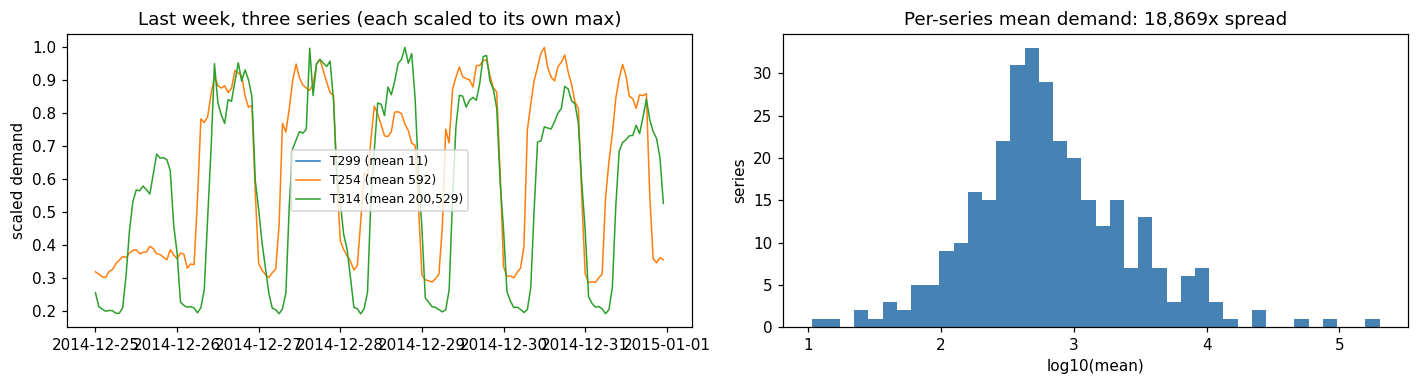

zero observations: 1.09% | series: 321 | history per series: 26,304 steps (~3.0 years)


In [4]:
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
means = wide.mean()
picks = [means.idxmin(), means.sort_values().index[len(means) // 2], means.idxmax()]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
week = wide.iloc[-WEEKLY:]
for sid in picks:
    axes[0].plot(week.index, week[sid] / week[sid].max(), lw=1.0,
                 label=f"{sid} (mean {means[sid]:,.0f})")
axes[0].set(title="Last week, three series (each scaled to its own max)", ylabel="scaled demand")
axes[0].legend(fontsize=8)
axes[1].hist(np.log10(means.clip(lower=1e-9)), bins=40, color="steelblue")
axes[1].set(title=f"Per-series mean demand: {means.max() / max(means.min(), 1e-9):,.0f}x spread",
            xlabel="log10(mean)", ylabel="series")
plt.tight_layout(); plt.savefig(FIG_DIR / "data_overview.png"); plt.show()

zero_share = float((wide.to_numpy() == 0).mean())
print(f"zero observations: {zero_share:.2%} | series: {len(SERIES)} | "
      f"history per series: {len(INDEX):,} steps (~{len(INDEX) / (24 * 365):.1f} years)")


## 5 — Evaluation protocol (frozen before any model runs)

The referee is defined once, here, and never touched again. `run_backtest` walks the shared
rolling-origin cutoffs and stores every model's nine quantile tracks in one tidy schema;
`evaluate` computes all metrics from those files; `update_leaderboard` maintains a single ranking.
A model only ever supplies a `model_fn(train_wide, h)` returning quantile arrays — no model code
can touch a metric, and every model is scored by byte-identical logic.

Two conventions used throughout: quantile forecasts are **capped** to `[0, CAP_MULT × past max]`
per series (demand is non-negative; the cap tames occasional variance blow-ups) and **sorted**
across quantile levels so intervals never cross. MASE is undefined for seasonally-constant
training series (zero denominator) — such series are excluded from MASE and counted transparently.


In [5]:
def make_windows(index, n_windows, horizon, step):
    """Non-overlapping rolling-origin windows walking back from the end of the data."""
    last_pos = len(index) - 1
    rows = []
    for k in range(n_windows):
        cutoff_pos = last_pos - horizon - k * step
        assert cutoff_pos - SEASONALITY >= 0, "not enough history for the requested windows"
        rows.append({"window": k, "cutoff_pos": cutoff_pos, "cutoff": index[cutoff_pos],
                     "first_forecast": index[cutoff_pos + 1],
                     "last_forecast": index[cutoff_pos + horizon]})
    return pd.DataFrame(rows).sort_values("window", ignore_index=True)


# --- Metrics (validated on synthetic data; all operate on (H, n_series) arrays) ---
def mae(y, p):  return np.abs(y - p).mean(axis=0)
def rmse(y, p): return np.sqrt(((y - p) ** 2).mean(axis=0))


def smape(y, p):
    den = np.abs(y) + np.abs(p)
    with np.errstate(invalid="ignore", divide="ignore"):
        val = np.where(den == 0, 0.0, 2.0 * np.abs(p - y) / den)
    return val.mean(axis=0) * 100.0


def seasonal_naive_denom(train_wide, m):
    """In-sample seasonal-naive MAE per series (the MASE scaling)."""
    a = train_wide.to_numpy()
    return np.abs(a[m:] - a[:-m]).mean(axis=0)


def mase(y, p, denom):
    d = np.where(denom == 0, np.nan, denom)
    return mae(y, p) / d


def pinball(y, q_pred, q):
    e = y - q_pred
    return np.maximum(q * e, (q - 1) * e)


def wql(y, quant_preds, levels):
    num = np.zeros(y.shape[1])
    for q in levels:
        num += 2.0 * pinball(y, quant_preds[q], q).sum(axis=0)
    denom = np.abs(y).sum(axis=0)
    denom = np.where(denom == 0, np.nan, denom)
    return (num / len(levels)) / denom


def coverage(y, lo, hi):
    return ((y >= lo) & (y <= hi)).mean(axis=0)


# --- Orchestration: backtest -> tidy forecast files -> centralized scoring -> one leaderboard ---
def run_backtest(model_fn, name, save=True):
    """model_fn(train_wide, h) returns an (h, n) array (point model, broadcast to all quantiles)
    or a dict {quantile: (h, n) array}; columns follow SERIES order."""
    n = len(SERIES)
    uid = np.tile(SERIES.to_numpy(), HORIZON)
    horizon_idx = np.repeat(np.arange(1, HORIZON + 1), n)
    blocks = []
    for _, w in windows.iterrows():
        pos = int(w["cutoff_pos"])
        train = wide.iloc[: pos + 1]
        y_true = wide.iloc[pos + 1: pos + 1 + HORIZON].to_numpy()
        ds = wide.index[pos + 1: pos + 1 + HORIZON]
        preds = model_fn(train, HORIZON)
        if not isinstance(preds, dict):
            preds = {q: preds for q in QUANTILE_LEVELS}
        block = pd.DataFrame({"model": name, "unique_id": uid, "cutoff": w["cutoff"],
                              "ds": np.repeat(ds.to_numpy(), n), "horizon": horizon_idx,
                              "y": y_true.reshape(-1)})
        for q, col in QCOLS.items():
            block[col] = np.asarray(preds[q]).reshape(-1)
        blocks.append(block)
    fc = pd.concat(blocks, ignore_index=True)
    if save:
        fc.to_parquet(FORECASTS / f"{name}.parquet", index=False)
        print(f"[{name}] saved {len(fc):,} forecast rows")
    return fc


OVERALLS = []


def evaluate(name, m=SEASONALITY, write=True):
    """Score one forecast file; returns (overall row, per-series-per-window frame)."""
    fc = pd.read_parquet(FORECASTS / f"{name}.parquet")

    def _pivot(g, col):
        return (g.pivot_table(index="horizon", columns="unique_id", values=col)
                 .reindex(columns=SERIES).to_numpy())

    per_window = []
    for cutoff, g in fc.groupby("cutoff", sort=True):
        pos = int(INDEX.get_loc(cutoff))
        denom = seasonal_naive_denom(wide.iloc[: pos + 1], m)
        y = _pivot(g, "y")
        p50 = _pivot(g, QCOLS[POINT_Q])
        quant = {q: _pivot(g, QCOLS[q]) for q in QUANTILE_LEVELS}
        per_window.append(pd.DataFrame({
            "cutoff": cutoff, "unique_id": SERIES,
            "MAE": mae(y, p50), "RMSE": rmse(y, p50), "sMAPE": smape(y, p50),
            "MASE": mase(y, p50, denom), "WQL": wql(y, quant, QUANTILE_LEVELS),
            "coverage80": coverage(y, quant[COVERAGE_LO], quant[COVERAGE_HI])}))
    per = pd.concat(per_window, ignore_index=True)
    overall = per[METRIC_COLS].mean(numeric_only=True)
    overall["model"] = name
    overall["n_excluded_MASE"] = int(per["MASE"].isna().sum())
    if write:
        per.to_csv(METRICS / f"{name}_per_series.csv", index=False)
        per.groupby("cutoff")[METRIC_COLS].mean().to_csv(METRICS / f"{name}_by_window.csv")
        pd.DataFrame([overall]).to_csv(METRICS / f"{name}_summary.csv", index=False)
    OVERALLS.append(overall)
    print(pd.DataFrame([overall])[["model", "MASE", "sMAPE", "WQL", "coverage80"]].to_string(index=False))
    return overall, per


def update_leaderboard(*overalls):
    cols = ["model", "MASE", "sMAPE", "RMSE", "MAE", "WQL", "coverage80", "n_excluded_MASE"]
    board = pd.DataFrame(list(overalls))[cols].sort_values("MASE", ignore_index=True)
    board.to_csv(METRICS / "leaderboard.csv", index=False)
    return board


windows = make_windows(INDEX, N_WINDOWS, HORIZON, HORIZON)
print(windows[["window", "cutoff", "first_forecast", "last_forecast"]].to_string(index=False))


 window              cutoff first_forecast       last_forecast
      0 2014-12-24 23:00:00     2014-12-25 2014-12-31 23:00:00
      1 2014-12-17 23:00:00     2014-12-18 2014-12-24 23:00:00
      2 2014-12-10 23:00:00     2014-12-11 2014-12-17 23:00:00
      3 2014-12-03 23:00:00     2014-12-04 2014-12-10 23:00:00
      4 2014-11-26 23:00:00     2014-11-27 2014-12-03 23:00:00


## 6 — Seasonal-naive references

`seasonal_naive(WEEKLY)` — literally *repeat last week* — is the bar every sophisticated model
must clear. These are point models: the backtest broadcasts the same values across all nine
quantiles, so their intervals (and coverage) are intentionally degenerate.


In [6]:
def seasonal_naive(m):
    def _fn(train_wide, h):
        last = train_wide.to_numpy()[-m:]
        reps = int(np.ceil(h / m))
        return np.tile(last, (reps, 1))[:h]
    return _fn


for m, name in [(SEASONALITY, f"seasonal_naive_{SEASONALITY}"), (WEEKLY, f"seasonal_naive_{WEEKLY}")]:
    t0 = time.time()
    run_backtest(seasonal_naive(m), name)
    evaluate(name)
    print(f"{name} finished in {(time.time() - t0) / 60:.1f} min\n")


[seasonal_naive_24] saved 269,640 forecast rows
            model   MASE   sMAPE    WQL  coverage80
seasonal_naive_24 1.2993 14.3281 0.1527      0.0445
seasonal_naive_24 finished in 0.0 min

[seasonal_naive_168] saved 269,640 forecast rows
             model   MASE   sMAPE    WQL  coverage80
seasonal_naive_168 1.1130 11.7106 0.1279      0.0953
seasonal_naive_168 finished in 0.0 min



## 7 — Classical per-series baselines

AutoTheta, AutoETS and MSTL (daily + weekly decomposition with an ETS trend forecaster), fit
independently per series on the most-recent `CONTEXT_SF` steps — classical fits scale poorly with
series length, and a bounded context keeps five backtest windows tractable. Their Gaussian
prediction intervals are mapped onto the nine quantiles, then capped and sorted like every model.


In [7]:
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, AutoTheta, MSTL, SeasonalNaive

CONTEXT_SF = 2016          # recent steps per series for the classical fits (past-only)
SF_LEVELS = [20, 40, 60, 80]
SF_NJOBS = -1              # parallel across series


def sf_level_to_qcols(point_col):
    """Map the nine quantiles to statsforecast's point + lo/hi interval columns."""
    m = {0.5: point_col}
    for lvl, (qlo, qhi) in {80: (0.1, 0.9), 60: (0.2, 0.8), 40: (0.3, 0.7), 20: (0.4, 0.6)}.items():
        m[qlo] = f"{point_col}-lo-{lvl}"
        m[qhi] = f"{point_col}-hi-{lvl}"
    return m


def make_sf_model_fn(model, point_col, context=CONTEXT_SF, levels=SF_LEVELS, n_jobs=SF_NJOBS,
                     cap_mult=CAP_MULT):
    qcolmap = sf_level_to_qcols(point_col)

    def _fn(train_wide, h):
        tw = train_wide.iloc[-context:]
        cap = (cap_mult * tw.max()).reindex(SERIES).to_numpy()
        long = (tw.reset_index()
                  .melt(id_vars="ds", var_name="unique_id", value_name="y")[["unique_id", "ds", "y"]])
        sf = StatsForecast(models=[model], freq=FREQ, n_jobs=n_jobs,
                           fallback_model=SeasonalNaive(season_length=SEASONALITY))
        fc = sf.forecast(df=long, h=h, level=levels)
        if "unique_id" not in fc.columns:
            fc = fc.reset_index()
        fc = fc.sort_values(["unique_id", "ds"])
        arrs = []
        for q in QUANTILE_LEVELS:
            piv = fc.pivot(index="ds", columns="unique_id", values=qcolmap[q]).reindex(columns=SERIES)
            arrs.append(np.clip(piv.to_numpy(), 0.0, cap))
        stacked = np.sort(np.stack(arrs, axis=0), axis=0)
        assert not np.isnan(stacked).any(), "unexpected NaN forecast (a series went missing)"
        return {q: stacked[i] for i, q in enumerate(QUANTILE_LEVELS)}

    return _fn


for model, point_col, name in [
    (AutoTheta(season_length=SEASONALITY), "AutoTheta", "auto_theta"),
    (AutoETS(season_length=SEASONALITY), "AutoETS", "auto_ets"),
    (MSTL(season_length=[SEASONALITY, WEEKLY], trend_forecaster=AutoETS(model="ZZN")), "MSTL", "mstl"),
]:
    t0 = time.time()
    run_backtest(make_sf_model_fn(model, point_col), name)
    evaluate(name)
    print(f"{name} finished in {(time.time() - t0) / 60:.1f} min\n")


[auto_theta] saved 269,640 forecast rows
     model   MASE   sMAPE    WQL  coverage80
auto_theta 1.7528 19.9307 0.2337      0.9559
auto_theta finished in 8.0 min

[auto_ets] saved 269,640 forecast rows
   model   MASE   sMAPE    WQL  coverage80
auto_ets 1.3988 17.4006 0.2335      0.8081
auto_ets finished in 10.7 min

[mstl] saved 269,640 forecast rows
model   MASE   sMAPE    WQL  coverage80
 mstl 1.2984 17.0084 0.1398      0.8843
mstl finished in 3.0 min



## 8 — Gradient boosting (global LightGBM)

One quantile-objective LightGBM per fitted level (q10/q50/q90) over lag, rolling and calendar
features, trained **globally** across all series with per-series standardization; the intermediate
quantiles are interpolated between the fitted ones. This is the strongest widely-deployed
industrial recipe and a very different failure mode from the per-series statistical models.


In [8]:
import lightgbm as lgb
from mlforecast import MLForecast
from mlforecast.target_transforms import LocalStandardScaler
from mlforecast.lag_transforms import RollingMean, RollingStd

CONTEXT_LGB = 8760                         # most-recent year per series (past-only)
LGB_Q = {0.1: "q10", 0.5: "q50", 0.9: "q90"}
LGB_LAGS = [1, SEASONALITY, 2 * SEASONALITY, WEEKLY, 2 * WEEKLY]


def is_weekend(dates):
    return (dates.dayofweek >= 5).astype("int8")


def make_lgb_models():
    common = dict(n_estimators=300, num_leaves=64, learning_rate=0.05, min_child_samples=200,
                  subsample=0.8, subsample_freq=1, colsample_bytree=0.9,
                  verbosity=-1, n_jobs=-1, random_state=RANDOM_SEED)
    return {name: lgb.LGBMRegressor(objective="quantile", alpha=a, **common)
            for a, name in LGB_Q.items()}


def lgb_model_fn(train_wide, h):
    tw = train_wide.iloc[-CONTEXT_LGB:]
    long = (tw.reset_index()
              .melt(id_vars="ds", var_name="unique_id", value_name="y")[["unique_id", "ds", "y"]])
    fcst = MLForecast(
        models=make_lgb_models(), freq=FREQ,
        lags=LGB_LAGS,
        lag_transforms={1: [RollingMean(window_size=SEASONALITY), RollingStd(window_size=SEASONALITY)],
                        SEASONALITY: [RollingMean(window_size=WEEKLY)],
                        WEEKLY: [RollingMean(window_size=WEEKLY)]},
        date_features=["hour", "dayofweek", "month", is_weekend],
        target_transforms=[LocalStandardScaler()],
    )
    fcst.fit(long, static_features=[])
    preds = fcst.predict(h=h).sort_values(["unique_id", "ds"])

    def piv(col):
        arr = preds.pivot(index="ds", columns="unique_id", values=col).reindex(columns=SERIES).to_numpy()
        return np.clip(arr, 0.0, None)

    q10, q50, q90 = piv("q10"), piv("q50"), piv("q90")
    q10 = np.minimum(q10, q50)
    q90 = np.maximum(q90, q50)
    out = {0.1: q10, 0.5: q50, 0.9: q90}
    for q in (0.2, 0.3, 0.4):
        out[q] = q10 + (q - 0.1) / 0.4 * (q50 - q10)
    for q in (0.6, 0.7, 0.8):
        out[q] = q50 + (q - 0.5) / 0.4 * (q90 - q50)
    return out


t0 = time.time()
run_backtest(lgb_model_fn, "lgbm_global")
evaluate("lgbm_global")
print(f"lgbm_global finished in {(time.time() - t0) / 60:.1f} min")


[lgbm_global] saved 269,640 forecast rows
      model   MASE   sMAPE    WQL  coverage80
lgbm_global 1.2073 14.3961 0.2828      0.9736
lgbm_global finished in 6.4 min


## 9 — PatchTST: a Transformer trained from scratch

PatchTST (Nie et al., ICLR 2023) slices each context window into overlapping patches and runs a
channel-independent Transformer encoder with reversible instance normalization (RevIN) — the
per-series normalization the scale spread demands, computed on past-only context. It trains with
a nine-quantile pinball loss, so its probabilistic output is learned, not assumed Gaussian.

**Budget discipline:** the step ceiling is only a safety net — **early stopping on a past-only
validation tail decides when training ends** (checked every `VAL_CHECK` steps, patience
`EARLY_STOP`). One full refit per backtest window; each fit's stop step is read back from its
training log, so the budget is observable, not assumed.


In [9]:
from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST
from neuralforecast.losses.pytorch import MQLoss

try:
    from pytorch_lightning.loggers import CSVLogger
except ImportError:
    from lightning.pytorch.loggers import CSVLogger

INPUT_SIZE    = 512      # ~3 weeks of context
PATCH_LEN     = 16
STRIDE        = 8
HIDDEN        = 128
N_HEADS       = 8
ENC_LAYERS    = 3
LINEAR_HIDDEN = 128
DROPOUT       = 0.2
LR            = 1e-3
BATCH_SIZE    = 32       # series per batch
WINDOWS_BATCH = 256      # sampled training windows per step
VAL_SIZE      = HORIZON  # past-only validation tail for early stopping
MAX_STEPS     = 50_000   # safety ceiling only; early stopping is the stop rule
VAL_CHECK     = 100
EARLY_STOP    = 5        # patience, in validation checks

# MQLoss orders its outputs by sorted quantile; map them onto q10..q90 robustly.
_QSUFFIX = MQLoss(quantiles=QUANTILE_LEVELS).output_names
QCOLMAP = {q: f"PatchTST{s}" for q, s in zip(QUANTILE_LEVELS, _QSUFFIX)}
STOP_STEPS = []


def build_patchtst(max_steps=MAX_STEPS, early_stop=EARLY_STOP, run_name="fit"):
    return PatchTST(
        h=HORIZON, input_size=INPUT_SIZE, patch_len=PATCH_LEN, stride=STRIDE,
        hidden_size=HIDDEN, n_heads=N_HEADS, encoder_layers=ENC_LAYERS,
        linear_hidden_size=LINEAR_HIDDEN, dropout=DROPOUT, revin=True,
        loss=MQLoss(quantiles=QUANTILE_LEVELS), learning_rate=LR,
        max_steps=max_steps, val_check_steps=VAL_CHECK, early_stop_patience_steps=early_stop,
        batch_size=BATCH_SIZE, windows_batch_size=WINDOWS_BATCH, random_seed=RANDOM_SEED,
        scaler_type="identity", accelerator="gpu", devices=1,
        enable_progress_bar=False, enable_checkpointing=False,
        logger=CSVLogger(save_dir=str(LOG_DIR), name=run_name),
    )


def _fitted_steps(run_name):
    """Steps a fit actually ran, read from its CSVLogger output (robust across versions)."""
    try:
        f = sorted((LOG_DIR / run_name).glob("version_*/metrics.csv"))[-1]
        return int(pd.read_csv(f)["step"].max()) + 1
    except Exception:
        return None


def patchtst_model_fn(train_wide, h):
    torch.manual_seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
    cap = (CAP_MULT * train_wide.max()).reindex(SERIES).to_numpy()
    long = (train_wide.reset_index()
            .melt(id_vars="ds", var_name="unique_id", value_name="y")[["unique_id", "ds", "y"]])
    k = len(STOP_STEPS)
    t0 = time.time()
    run_name = f"patchtst_window_{k}"
    nf = NeuralForecast(models=[build_patchtst(run_name=run_name)], freq=FREQ)
    nf.fit(df=long, val_size=VAL_SIZE)
    steps = _fitted_steps(run_name)
    STOP_STEPS.append(steps)
    ceiling = " — CEILING HIT, raise MAX_STEPS" if steps is not None and steps >= MAX_STEPS else ""
    print(f"[window {k}] stopped at step {steps} in {(time.time() - t0) / 60:.1f} min{ceiling}")
    fc = nf.predict()
    if "unique_id" not in fc.columns:
        fc = fc.reset_index()
    arrs = []
    for q in QUANTILE_LEVELS:
        piv = fc.pivot(index="ds", columns="unique_id", values=QCOLMAP[q]).reindex(columns=SERIES)
        arrs.append(np.clip(piv.to_numpy(), 0.0, cap))
    stacked = np.sort(np.stack(arrs, axis=0), axis=0)
    assert not np.isnan(stacked).any(), "unexpected NaN forecast (a series went missing)"
    return {q: stacked[i] for i, q in enumerate(QUANTILE_LEVELS)}


t0 = time.time()
run_backtest(patchtst_model_fn, "patchtst")
evaluate("patchtst")
print(f"\npatchtst backtest finished in {(time.time() - t0) / 60:.1f} min "
      f"| stop steps per window: {STOP_STEPS}")


INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MQLoss            | 9      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 12.7 M | train
-----------------------------------------------------------
12.7 M    Trainable params
12        Non-trainable params
12.7 M    Total params
50.788    Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode
INFO:pytorch_lightning.utilities.rank_zero:Trainer already configure

[window 0] stopped at step 1800 in 0.8 min


INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MQLoss            | 9      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 12.7 M | train
-----------------------------------------------------------
12.7 M    Trainable params
12        Non-trainable params
12.7 M    Total params
50.788    Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode
INFO:pytorch_lightning.utilities.rank_zero:Trainer already configure

[window 1] stopped at step 2500 in 1.1 min


INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MQLoss            | 9      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 12.7 M | train
-----------------------------------------------------------
12.7 M    Trainable params
12        Non-trainable params
12.7 M    Total params
50.788    Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode
INFO:pytorch_lightning.utilities.rank_zero:Trainer already configure

[window 2] stopped at step 1600 in 0.7 min


INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MQLoss            | 9      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 12.7 M | train
-----------------------------------------------------------
12.7 M    Trainable params
12        Non-trainable params
12.7 M    Total params
50.788    Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode
INFO:pytorch_lightning.utilities.rank_zero:Trainer already configure

[window 3] stopped at step 2300 in 1.0 min


INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MQLoss            | 9      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 12.7 M | train
-----------------------------------------------------------
12.7 M    Trainable params
12        Non-trainable params
12.7 M    Total params
50.788    Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode
INFO:pytorch_lightning.utilities.rank_zero:Trainer already configure

[window 4] stopped at step 2000 in 0.8 min
[patchtst] saved 269,640 forecast rows
   model   MASE   sMAPE    WQL  coverage80
patchtst 1.7116 20.0961 0.1517      0.7209

patchtst backtest finished in 4.4 min | stop steps per window: [1800, 2500, 1600, 2300, 2000]


## 10 — Chronos-Bolt, zero-shot

A time-series foundation model: pretrained on a large corpus of series, applied here with **no
training at all** — it reads the most-recent 2048 steps of each series and directly emits all nine
quantiles. Post-processing (cap + sort) is identical to every other model, so the comparison is
exactly like-for-like. Horizons beyond Bolt's native 64-step block are produced by rolling
forward (natively where the library supports it, otherwise via an explicit median-feedback loop).


In [10]:
import importlib.metadata

from chronos import BaseChronosPipeline

CONTEXT_CHRONOS = 2048         # Bolt's maximum context window
BOLT_CHUNK = 64                # Bolt's native direct-forecast length
CHRONOS_MODELS = {"chronos_bolt_small": "amazon/chronos-bolt-small",
                  "chronos_bolt_base": "amazon/chronos-bolt-base"}


def chronos_quantile_forecast(pipe, train_wide, h):
    """Nine capped, sorted (h, n_series) quantile arrays from a Chronos-Bolt pipeline."""
    tw = train_wide.iloc[-CONTEXT_CHRONOS:]
    cap = (CAP_MULT * tw.max()).reindex(SERIES).to_numpy()
    ctx = torch.tensor(tw[SERIES].to_numpy().T, dtype=torch.float32)      # (n_series, context)
    try:
        q, _ = pipe.predict_quantiles(context=ctx, prediction_length=h,
                                      quantile_levels=QUANTILE_LEVELS,
                                      limit_prediction_length=False)
    except (TypeError, ValueError):
        qs, cur, remaining = [], ctx, h
        while remaining > 0:
            step = min(BOLT_CHUNK, remaining)
            qq, _ = pipe.predict_quantiles(context=cur, prediction_length=step,
                                           quantile_levels=QUANTILE_LEVELS)
            qs.append(qq)
            med = qq[:, :, QUANTILE_LEVELS.index(0.5)].to(cur.dtype)      # roll forward on the median
            cur = torch.cat([cur, med.cpu()], dim=1)[:, -CONTEXT_CHRONOS:]
            remaining -= step
        q = torch.cat(qs, dim=1)
    q = q.to(torch.float32).cpu().numpy()                                 # (n_series, h, 9)
    arrs = [np.clip(q[:, :, i].T, 0.0, cap) for i in range(len(QUANTILE_LEVELS))]
    stacked = np.sort(np.stack(arrs, axis=0), axis=0)
    assert not np.isnan(stacked).any(), "unexpected NaN forecast (a series went missing)"
    return {qv: stacked[i] for i, qv in enumerate(QUANTILE_LEVELS)}


for name, hf_id in CHRONOS_MODELS.items():
    t0 = time.time()
    pipe = BaseChronosPipeline.from_pretrained(hf_id, device_map="cuda", torch_dtype=torch.bfloat16)
    run_backtest(lambda tw, h, p=pipe: chronos_quantile_forecast(p, tw, h), name)
    evaluate(name)
    del pipe
    torch.cuda.empty_cache()
    print(f"{name} finished in {(time.time() - t0) / 60:.1f} min (zero-shot, no training)\n")


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/191M [00:00<?, ?B/s]

[chronos_bolt_small] saved 269,640 forecast rows
             model   MASE   sMAPE    WQL  coverage80
chronos_bolt_small 0.9754 11.1097 0.0920      0.7100
chronos_bolt_small finished in 0.1 min (zero-shot, no training)



config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/821M [00:00<?, ?B/s]

[chronos_bolt_base] saved 269,640 forecast rows
            model   MASE   sMAPE    WQL  coverage80
chronos_bolt_base 0.9378 10.6786 0.0900      0.7118
chronos_bolt_base finished in 0.1 min (zero-shot, no training)



## 11 — Chronos-Bolt, fine-tuned

The zero-shot result asks an obvious follow-up: does a light fine-tune on this dataset's own
history help? The loop below continues training `chronos-bolt-base` on randomly sampled
(context 2048 → target 64) windows drawn from **past-only** data, with early stopping on a
held-out tail — the same budget discipline as PatchTST. For an honest leaderboard row the model
is re-fine-tuned from the pretrained checkpoint once per backtest window; the final shareable
model is then fine-tuned on the full history.


In [11]:
FT_BASE = "amazon/chronos-bolt-base"
FT_NAME = "chronos_bolt_base_ft"
FT_MAX_STEPS = 3000            # safety ceiling; early stopping is the stop rule
FT_VAL_CHECK = 50
FT_PATIENCE = 5                # in validation checks
FT_LR = 1e-5
FT_BATCH = 24
FT_STOP_STEPS = []


def _sample_ft_batch(arr, ctx_len, batch, rng):
    """Random (context, next-64-target) windows across series and time. arr: (T, n) float32."""
    T, n = arr.shape
    ctx = np.empty((batch, ctx_len), dtype=np.float32)
    tgt = np.empty((batch, BOLT_CHUNK), dtype=np.float32)
    for b in range(batch):
        j = rng.integers(0, n)
        end = rng.integers(ctx_len, T - BOLT_CHUNK + 1)
        ctx[b] = arr[end - ctx_len:end, j]
        tgt[b] = arr[end:end + BOLT_CHUNK, j]
    return torch.from_numpy(ctx), torch.from_numpy(tgt)


def fine_tune_bolt(train_wide, run_name, max_steps=FT_MAX_STEPS):
    """Continue training Chronos-Bolt on past-only windows; early-stop on the last 64 steps
    (held out from sampling) and restore the best weights. Returns the fine-tuned pipeline."""
    torch.manual_seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
    rng = np.random.default_rng(RANDOM_SEED)
    pipe = BaseChronosPipeline.from_pretrained(FT_BASE, device_map="cuda",
                                               torch_dtype=torch.float32)
    model = pipe.model
    dev = next(model.parameters()).device
    arr = train_wide[SERIES].to_numpy(dtype=np.float32)
    ctx_len = min(CONTEXT_CHRONOS, arr.shape[0] - 2 * BOLT_CHUNK)
    train_arr = arr[:-BOLT_CHUNK]                                     # last 64 steps held out for val
    vctx = torch.from_numpy(arr[-(ctx_len + BOLT_CHUNK):-BOLT_CHUNK].T.copy())
    vtgt = torch.from_numpy(arr[-BOLT_CHUNK:].T.copy())

    def val_loss():
        model.eval()
        losses = []
        with torch.no_grad():
            for i in range(0, vctx.shape[0], 64):
                out = model(context=vctx[i:i + 64].to(dev), target=vtgt[i:i + 64].to(dev))
                losses.append(float(out.loss))
        model.train()
        return float(np.mean(losses))

    opt = torch.optim.AdamW(model.parameters(), lr=FT_LR)
    best, best_state, since_best, curve = np.inf, None, 0, []
    t0 = time.time()
    model.train()
    for step in range(1, max_steps + 1):
        ctx, tgt = _sample_ft_batch(train_arr, ctx_len, FT_BATCH, rng)
        out = model(context=ctx.to(dev), target=tgt.to(dev))
        assert out.loss is not None, "chronos model returned no loss — fine-tuning API changed?"
        opt.zero_grad()
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        if step % FT_VAL_CHECK == 0:
            vl = val_loss()
            curve.append({"step": step, "val_loss": vl})
            if vl < best - 1e-5:
                best, since_best = vl, 0
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            else:
                since_best += 1
                if since_best >= FT_PATIENCE:
                    break
    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    pd.DataFrame(curve).to_csv(LOG_DIR / f"{run_name}_val_curve.csv", index=False)
    ceiling = " — CEILING HIT, raise FT_MAX_STEPS" if step >= max_steps else ""
    print(f"[{run_name}] stopped at step {step} in {(time.time() - t0) / 60:.1f} min "
          f"| best val loss {best:.4f}{ceiling}")
    return pipe, step


def chronos_ft_model_fn(train_wide, h):
    pipe, stopped = fine_tune_bolt(train_wide, run_name=f"ft_window_{len(FT_STOP_STEPS)}")
    FT_STOP_STEPS.append(stopped)
    out = chronos_quantile_forecast(pipe, train_wide, h)
    del pipe
    torch.cuda.empty_cache()
    return out


t0 = time.time()
run_backtest(chronos_ft_model_fn, FT_NAME)
evaluate(FT_NAME)
print(f"\n{FT_NAME} backtest finished in {(time.time() - t0) / 60:.1f} min "
      f"| stop steps per window: {FT_STOP_STEPS}")


[ft_window_0] stopped at step 500 in 1.1 min | best val loss 18.4560
[ft_window_1] stopped at step 350 in 0.8 min | best val loss 10.8969
[ft_window_2] stopped at step 650 in 1.5 min | best val loss 14.7768
[ft_window_3] stopped at step 500 in 1.1 min | best val loss 10.7957
[ft_window_4] stopped at step 500 in 1.1 min | best val loss 10.0839
[chronos_bolt_base_ft] saved 269,640 forecast rows
               model   MASE   sMAPE    WQL  coverage80
chronos_bolt_base_ft 0.9358 10.8274 0.0896      0.7014

chronos_bolt_base_ft backtest finished in 5.8 min | stop steps per window: [500, 350, 650, 500, 500]


## 12 — Leaderboard

Every row was produced in this notebook, in this session, by the same protocol and metric code.
MASE below 1.0 means beating even the *in-sample* seasonal-naive scaling; the operative bar is
the out-of-sample seasonal naive row.


In [12]:
uniq = {o["model"]: o for o in OVERALLS}                    # last run wins if a cell was re-executed
board = update_leaderboard(*uniq.values())
bar_name = f"seasonal_naive_{WEEKLY}"
ref = board.loc[board["model"] == bar_name, "MASE"].iloc[0]
board["vs_bar_%"] = (board["MASE"] / ref - 1.0) * 100.0
print("Leaderboard (sorted by MASE, the primary metric):\n")
print(board[["model", "MASE", "sMAPE", "RMSE", "WQL", "coverage80", "vs_bar_%"]]
      .to_string(index=False))

print(f"\n--- Verdicts vs the {bar_name} bar (MASE {ref:.4f}) ---")
for name in ["patchtst", *CHRONOS_MODELS, FT_NAME]:
    row = board.loc[board["model"] == name]
    if row.empty:
        continue
    m = row["MASE"].iloc[0]
    verdict = "BEATS" if m < ref else "does NOT beat"
    print(f"  {name:22s} MASE {m:.4f}  ->  {verdict} the bar ({(m / ref - 1) * 100:+.1f}%)")


Leaderboard (sorted by MASE, the primary metric):

               model   MASE   sMAPE     RMSE    WQL  coverage80  vs_bar_%
chronos_bolt_base_ft 0.9358 10.8274 223.4578 0.0896      0.7014  -15.9229
   chronos_bolt_base 0.9378 10.6786 224.0305 0.0900      0.7118  -15.7408
  chronos_bolt_small 0.9754 11.1097 237.0173 0.0920      0.7100  -12.3622
  seasonal_naive_168 1.1130 11.7106 276.1232 0.1279      0.0953    0.0000
         lgbm_global 1.2073 14.3961 280.7071 0.2828      0.9736    8.4767
                mstl 1.2984 17.0084 299.2739 0.1398      0.8843   16.6582
   seasonal_naive_24 1.2993 14.3281 315.0868 0.1527      0.0445   16.7386
            auto_ets 1.3988 17.4006 310.2118 0.2335      0.8081   25.6822
            patchtst 1.7116 20.0961 378.9019 0.1517      0.7209   53.7788
          auto_theta 1.7528 19.9307 464.2400 0.2337      0.9559   57.4867

--- Verdicts vs the seasonal_naive_168 bar (MASE 1.1130) ---
  patchtst               MASE 1.7116  ->  does NOT beat the bar (+53.8%)


## 13 — The shareable model

The deliverable: `chronos-bolt-base` fine-tuned on the **full history** with the same early-stopped
recipe, saved in standard Hugging Face format (`config.json` + safetensors) so anyone can load it
with one `from_pretrained` call — plus an auto-generated model card carrying this notebook's
benchmark numbers. A reload-and-predict check confirms the artifact is self-contained.


In [13]:
HF_REPO_ID = "your-username/chronos-bolt-base-electricity"     # <- set to your HF username/repo

pipe_final, final_steps = fine_tune_bolt(wide, run_name="ft_final")
SHARE_DIR = MODELS_DIR / FT_NAME
pipe_final.model.save_pretrained(SHARE_DIR)                     # config.json + model.safetensors
del pipe_final
torch.cuda.empty_cache()

# --- reload-and-predict check: the artifact must stand on its own ---
pipe_reload = BaseChronosPipeline.from_pretrained(SHARE_DIR, device_map="cuda",
                                                  torch_dtype=torch.bfloat16)
_probe = chronos_quantile_forecast(pipe_reload, wide, HORIZON)
assert _probe[0.5].shape == (HORIZON, len(SERIES))
del pipe_reload
torch.cuda.empty_cache()
print(f"reload check OK — {SHARE_DIR} predicts H={HORIZON} for {len(SERIES)} series")

# --- model card with this run's benchmark numbers ---
def _row(name):
    r = board.loc[board["model"] == name].iloc[0]
    return f"| `{name}` | {r['MASE']:.4f} | {r['WQL']:.4f} | {r['coverage80']:.3f} |"

dataset_desc = (CUSTOM_DATA or "Monash electricity_hourly (321 hourly series, 2012-2014, "
                               "aggregated from UCI ElectricityLoadDiagrams20112014)")
card = f"""---
license: apache-2.0
base_model: amazon/chronos-bolt-base
pipeline_tag: time-series-forecasting
tags:
- time-series
- forecasting
- chronos
- electricity
---

# chronos-bolt-base, fine-tuned on hourly electricity demand

`amazon/chronos-bolt-base` fine-tuned on {dataset_desc}.
Fine-tuning: randomly sampled (context {CONTEXT_CHRONOS} -> target {BOLT_CHUNK}) windows,
AdamW lr={FT_LR}, batch {FT_BATCH}, early stopping on a held-out tail
(stopped at step {final_steps}; ceiling {FT_MAX_STEPS}). Seed {RANDOM_SEED}.

## Benchmark ({N_WINDOWS} rolling-origin windows x {HORIZON}-step horizon, this training run)

| model | MASE | WQL | coverage@80 |
|---|---|---|---|
{_row(f"seasonal_naive_{WEEKLY}")}
{_row("chronos_bolt_base")}
{_row(FT_NAME)}

Lower MASE/WQL is better; the full leaderboard (classical baselines, LightGBM, PatchTST) and the
evaluation protocol are in the companion notebook.

## Usage

```python
import torch
from chronos import BaseChronosPipeline

pipe = BaseChronosPipeline.from_pretrained("{HF_REPO_ID}",
                                           device_map="cuda", torch_dtype=torch.bfloat16)
quantiles, mean = pipe.predict_quantiles(
    context=torch.tensor(history),          # (n_series, <=2048), most recent last
    prediction_length=64,
    quantile_levels=[0.1, 0.5, 0.9],
)
```

Horizons beyond 64 steps: predict in blocks of 64, feeding the median back as context.

## Limitations

Fine-tuned for hourly demand with strong daily/weekly cycles; expect degraded transfer to other
frequencies or domains (start from `amazon/chronos-bolt-base` instead). Quantiles are the model's
own; coverage was ~71-75% for nominal 80% on this benchmark — recalibrate (e.g. conformal) if you
need guaranteed coverage.
"""
(SHARE_DIR / "README.md").write_text(card)
print("model card written -> ", SHARE_DIR / "README.md")
print(*sorted(p.name for p in SHARE_DIR.iterdir()), sep="\n")


[ft_final] stopped at step 400 in 0.9 min | best val loss 26.8615
reload check OK — /content/outputs/models/chronos_bolt_base_ft predicts H=168 for 321 series
model card written ->  /content/outputs/models/chronos_bolt_base_ft/README.md
README.md
config.json
model.safetensors


## 14 — Outputs

Everything this run produced, in one folder (and one zip): per-model forecast files in a tidy
schema, all metric tables, the leaderboard, training logs / validation curves, and the shareable
fine-tuned model.


In [15]:
import shutil

run_meta = {
    "device": torch.cuda.get_device_name(0), "torch": torch.__version__,
    "numpy": np.__version__, "pandas": pd.__version__,
    **{k: __import__(k).__version__ for k in ["statsforecast", "mlforecast", "lightgbm", "neuralforecast"]},
    "chronos-forecasting": importlib.metadata.version("chronos-forecasting"),
    "dataset": CUSTOM_DATA or "monash_electricity_hourly",
    "patchtst_stop_steps": STOP_STEPS,
    "chronos_ft_stop_steps": FT_STOP_STEPS, "chronos_ft_final_steps": final_steps,
    "models_run": sorted(p.stem for p in FORECASTS.glob("*.parquet")),
}
(WORK / "run_meta.json").write_text(json.dumps(run_meta, indent=2, default=str))

zip_path = shutil.make_archive(str(WORK.parent / "energy_forecasting_outputs"), "zip", WORK)
print("outputs:", zip_path, f"({Path(zip_path).stat().st_size / 1e6:.1f} MB)")

if DRIVE_DIR is not None and DRIVE_DIR.exists():                  # survives a disconnected tab
    shutil.copy2(zip_path, DRIVE_DIR / "energy_forecasting_outputs.zip")
    print("copied to Drive: MyDrive/energy_forecasting_outputs.zip")
try:
    from google.colab import files
    files.download(zip_path)                                      # browser download (tab must be open)
except Exception:
    print("(not on Colab — grab the zip from the file browser)")


outputs: /content/energy_forecasting_outputs.zip (939.8 MB)
copied to Drive: MyDrive/energy_forecasting_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>